 # Outlier detection using IQR

 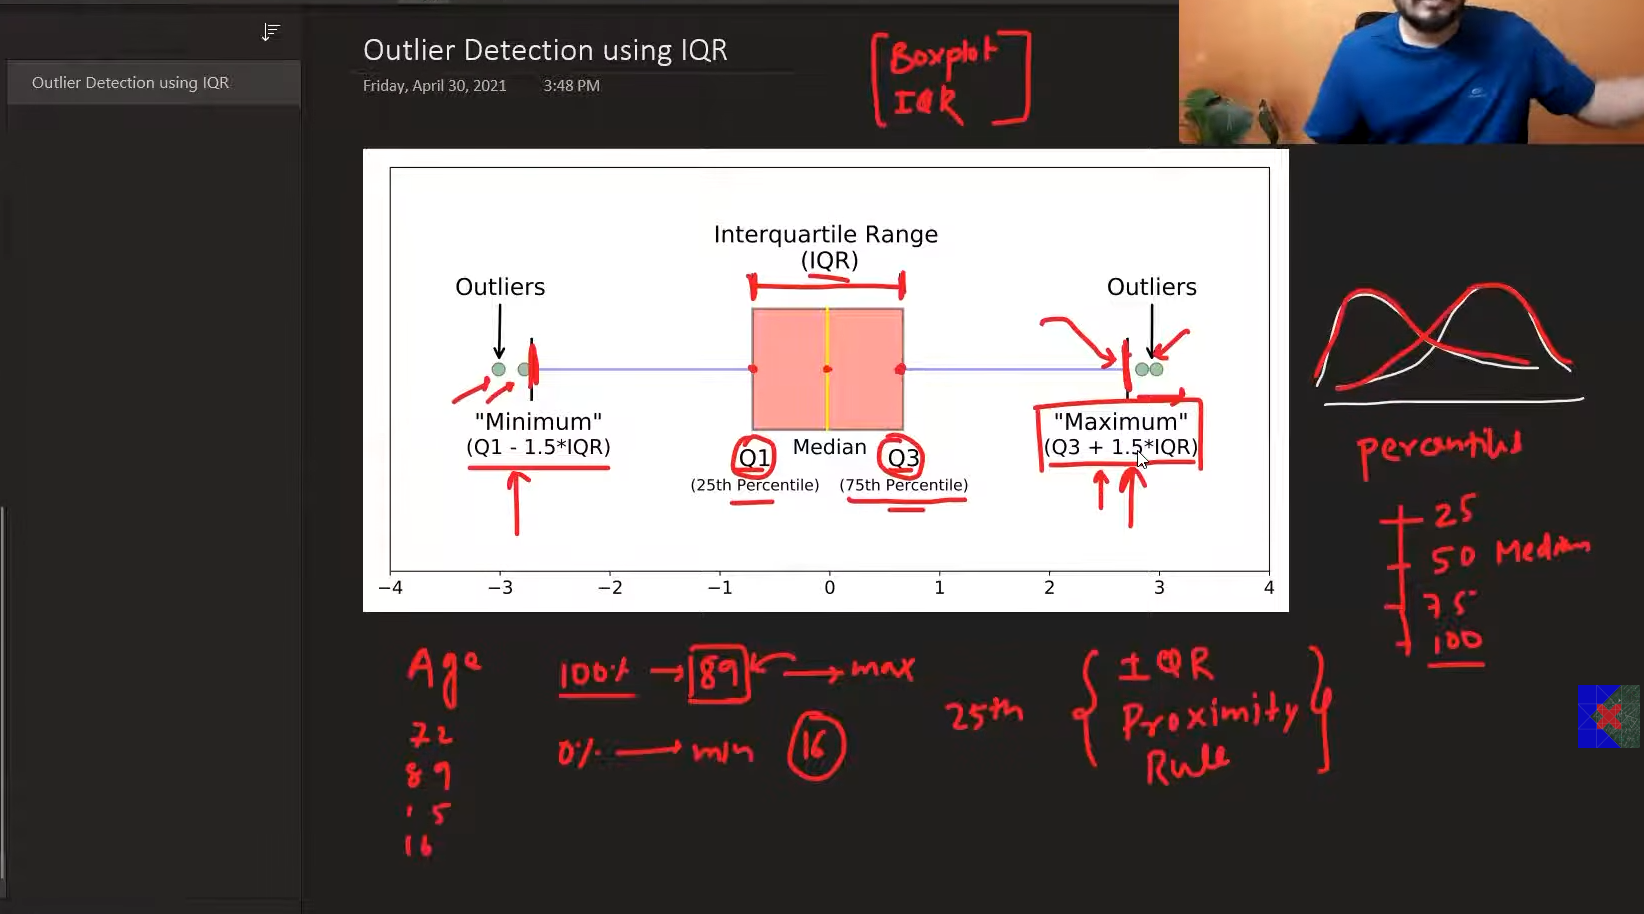

 1. IQR: The difference between Quartile 3 (Q_3) and Quartile 1 (Q_1).
 
    Maximum Limit: Q_3 + (1.5 \times IQR)

    Minimum Limit: Q_1 - (1.5 \times IQR)

 Outliers: Any data points that fall outside this maximum and minimum range.

2 .  Step-by-Step 

 *  Find a column of data that is skewed (not normally distributed).
 *  Calculate Q_1, Q_3, the IQR, and the maximum and minimum limits.
 *  Check the data points—anything lying outside of this safe range is treated as an outlier.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('placement.csv')

In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
437,6.73,22.0,0
818,5.52,62.0,0
528,6.90,38.0,1
352,6.51,4.0,1
56,6.93,15.0,1


In [6]:
df.shape

(1000, 3)

C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_20952\1017406459.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_20952\1017406459.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

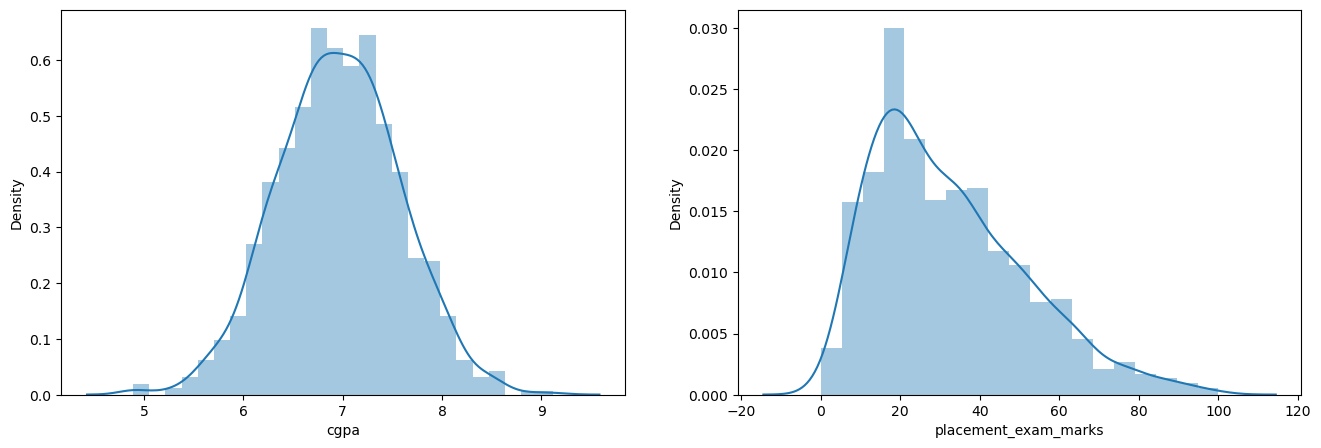

In [9]:
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

In [13]:
print(df['cgpa'].skew())
print(df['placement_exam_marks'].skew())

-0.014529938929314918
0.8356419499466834


In [17]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

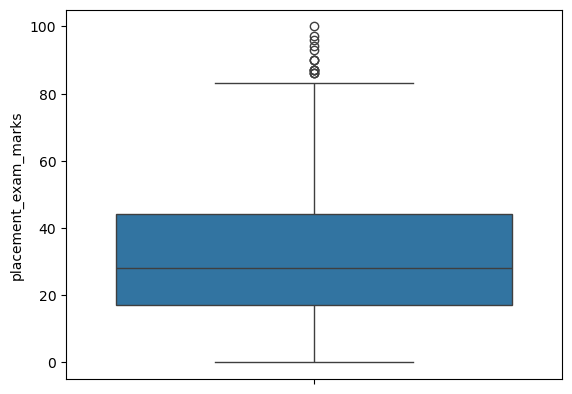

In [18]:
sns.boxplot(df['placement_exam_marks'])

In [23]:
percentile25 = df['placement_exam_marks'].quantile(0.25) # Q1
percentile75 = df['placement_exam_marks'].quantile(0.75)  # Q3

In [24]:
percentile25

np.float64(17.0)

In [25]:
percentile75

np.float64(44.0)

In [28]:
iqr = percentile75 - percentile25

In [29]:
iqr

np.float64(27.0)

In [30]:
upperlimit = percentile75 + 1.5 *iqr
lowerlimit = percentile25 - 1.5 *iqr

In [33]:
print('upperlimit', upperlimit)
print('lowerlimit', lowerlimit)

upperlimit 84.5
lowerlimit -23.5


# finding outliers

In [38]:
df[df['placement_exam_marks'] >upperlimit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [39]:
df[df['placement_exam_marks'] < lowerlimit]

,cgpa,placement_exam_marks,placed


# Trimming

In [44]:
new_df = df[df['placement_exam_marks'] < upperlimit]

In [45]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_20952\3185060281.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_20952\3185060281.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placeme

<Axes: ylabel='placement_exam_marks'>

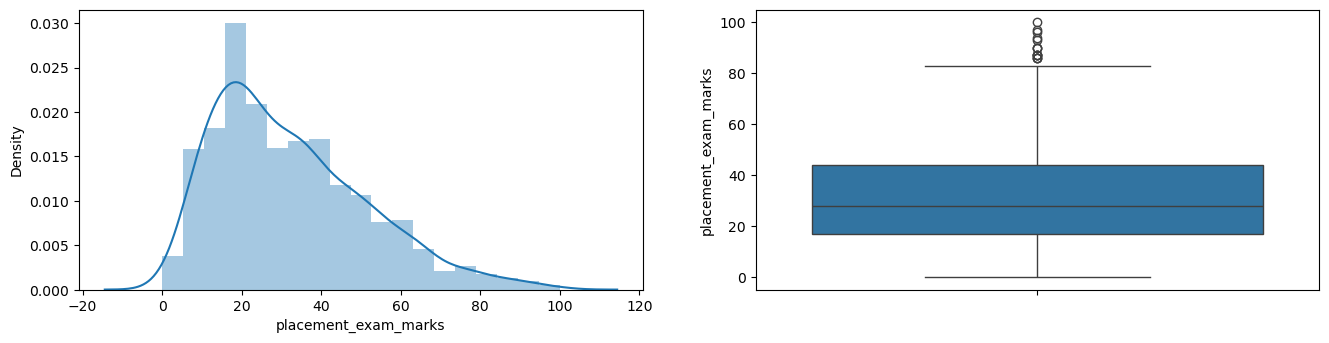

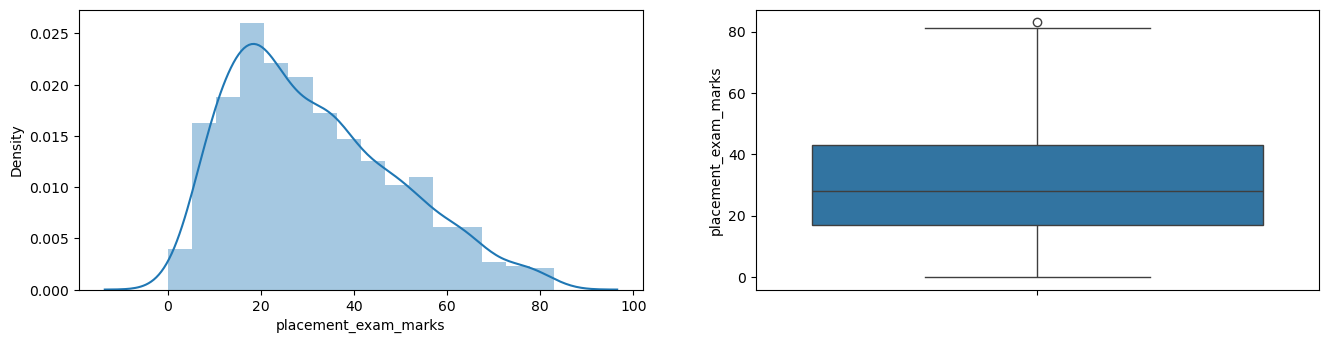

In [55]:
plt.figure(figsize = (16,8)) 
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])



plt.figure(figsize = (16,8)) 
plt.subplot(2,2,1)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(new_df['placement_exam_marks'])

# capping

In [59]:
new_df_cap = df.copy()

In [65]:
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks']>upperlimit,
    upperlimit,
    np.where(
        new_df_cap['placement_exam_marks'] < lowerlimit,
        lowerlimit,
        new_df_cap['placement_exam_marks']
    )
)

In [70]:
new_df_cap.shape

(1000, 3)

In [71]:
# comparing 

C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_20952\3062763066.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_20952\3062763066.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['plac

<Axes: ylabel='placement_exam_marks'>

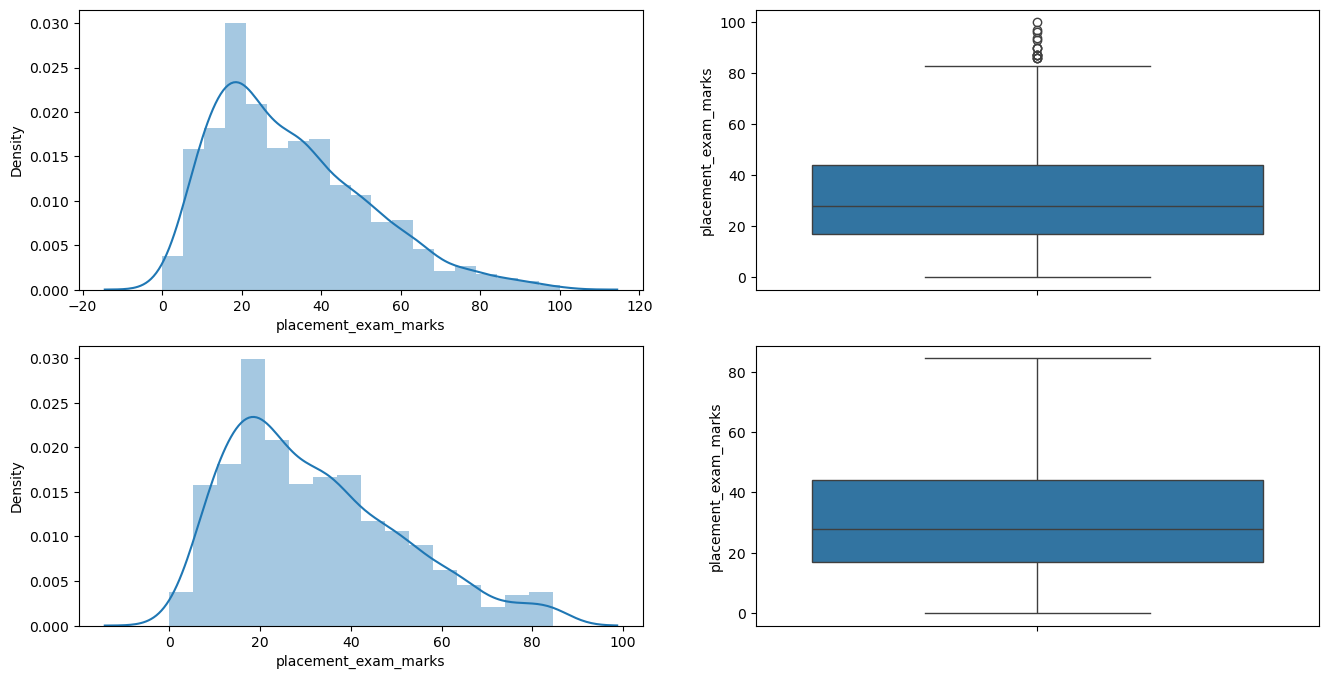

In [74]:
plt.figure(figsize = (16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])


plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])